In [1]:
from pipeline_functions import *
import torch
import snntorch.spikeplot as splt
import matplotlib.pyplot as plt
import numpy as np

import time

Raw data shape: (32, 117120)
(8, 307, 1800)
Raw data shape: (32, 117120)
Subject 1 loaded. Size: (8, 307, 1800)
Raw data shape: (32, 117120)
Subject 2 loaded. Size: (8, 307, 1800)
Raw data shape: (32, 117120)
Subject 3 loaded. Size: (8, 307, 1800)
Raw data shape: (32, 117120)
Subject 4 loaded. Size: (8, 307, 1800)
Raw data shape: (32, 117120)
Subject 5 loaded. Size: (8, 307, 1800)
Raw data shape: (32, 117120)
Subject 6 loaded. Size: (8, 307, 1800)
Raw data shape: (32, 117120)
Subject 7 loaded. Size: (8, 307, 1800)
Raw data shape: (32, 117120)
Subject 8 loaded. Size: (8, 307, 1800)
Raw data shape: (32, 117120)
Subject 9 loaded. Size: (8, 307, 1800)
Raw data shape: (32, 117120)
Subject 10 loaded. Size: (8, 307, 1800)
Raw data shape: (32, 117120)
Subject 11 loaded. Size: (8, 307, 1800)
Raw data shape: (32, 117120)
Subject 12 loaded. Size: (8, 307, 1800)
Raw data shape: (32, 117120)
Subject 13 loaded. Size: (8, 307, 1800)
Raw data shape: (32, 117120)
Subject 14 loaded. Size: (8, 307, 1800)

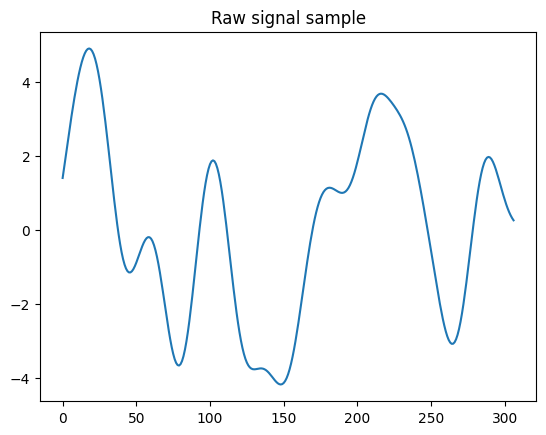

In [2]:
total_start = time.perf_counter()
file_path = f"C:/Users/crims/Desktop/Senior Design Code/datasets/Won2022_BIDS/.mat_files/s01.mat"
# preprocessing
t1 = time.perf_counter()
X, y, chars = fn_preprocess.preprocess_testing(file_path, use_training=True)
preprocess_time = (time.perf_counter() - t1) * 1000  # Convert to ms
print(X.shape)
X = np.empty((8, 307, 99000), dtype=np.float32)
y = np.empty((99000,), dtype=np.float32)
chars = ''  # Initialize chars as an empty list to store character labels

# loads data for all 55 subjects and preprocesses it
x_idx, y_idx = 0, 0
for num_subj in range(55): #WARNING, very long!
    file_name = f"C:/Users/crims/Desktop/Senior Design Code/datasets/Won2022_BIDS/.mat_files/s{num_subj+1:02d}.mat"
    # print(f"Loading {file_name}")
    X_subj, y_subj, char_subj= fn_preprocess.preprocess_testing(file_name, use_training=True)

    epoch_num = X_subj.shape[2]
    y_len = y_subj.shape[0]
    
    X[:, :, x_idx:x_idx+epoch_num] = X_subj.astype(np.float32, copy=False)
    y[y_idx:y_idx+y_len] = y_subj.astype(np.float32, copy=False)
    chars += char_subj  # Append character labels to the chars list

    x_idx += epoch_num
    y_idx += y_len

    print(f"Subject {num_subj+1} loaded. Size: {X_subj.shape}")

print(f"Total data shape: {X.shape}, Total labels shape: {y.shape}, Total chars length: {len(chars)}")

plt.plot(X[0, :, 0])  # trial 0, channel 0
plt.title("Raw signal sample")
plt.show()


X shape: (99000, 8, 307)
Shape after feature extraction: (99000, 8, 34)


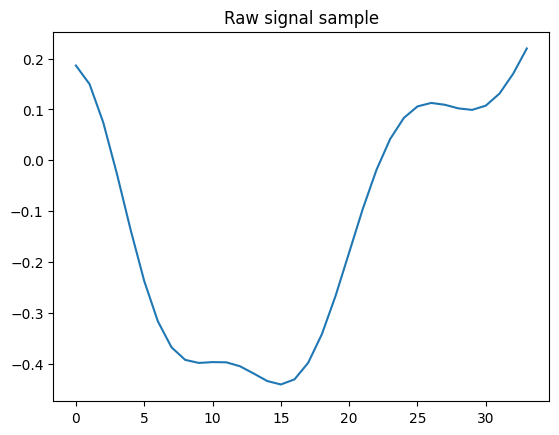

In [10]:

# feature extraction
t2 = time.perf_counter()
X_fe, y_fe = fn_feature_extraction.extractFeatures(X, y, k=1, t_min=200, t_max=400, norm_type='std', factor=3)
fe_time = (time.perf_counter() - t2) * 1000

plt.plot(X_fe[0, 0, :])  # trial 0, channel 0
plt.title("Raw signal sample")
plt.show()



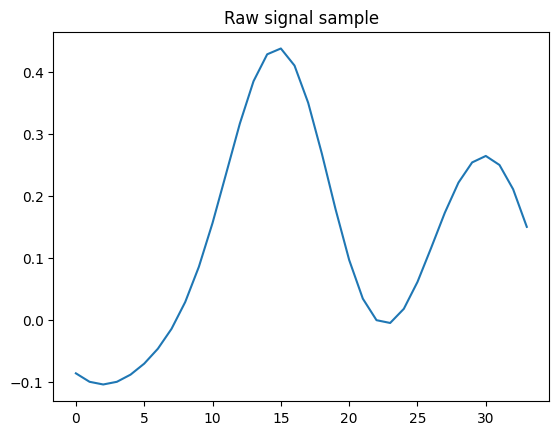

(99000, 34, 8)
[-1  0  0  0  0  0  0  0  0  0  0  1  1  0  0  0  0  0 -1 -1 -1  0  0  0
  0  0  0  0  0  0  0  0  0  0]


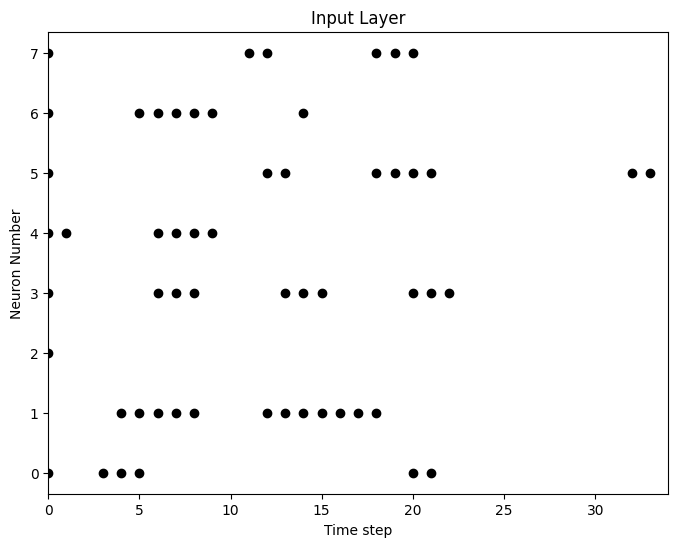

In [11]:
plt.plot(X_fe[0, 7, :])  # trial 0, channel 0
plt.title("Raw signal sample")
plt.show()

X_encoded = delta_encoding.delta_encode(X_fe, threshold=0.08) #spike encoding to implement
print(X_encoded.shape)
# Create fig, ax
fig = plt.figure(facecolor="w", figsize=(8, 6))
ax = fig.add_subplot(111)

print(X_encoded[0, :, 7])
trial_spikes = torch.from_numpy(X_encoded[0, :, :])

# Raster plot of delta converted data
splt.raster(trial_spikes, ax, c="black")

plt.title("Input Layer")
plt.xlabel("Time step")
plt.ylabel("Neuron Number")
plt.xlim(0, X_encoded.shape[1])
plt.show()


In [12]:

# create module
snn = SNNModule.createSNN(8, [256, 128], betas=[0.95, 0.95, 0.95], thresholds=[1, 1, 1])

# load in weights
# weights_path = "C:/Users/crims/Desktop/Senior Design Code/VirtualKeyboard/model_weights/3avg1/checkpoint_e45.tar"
# weights = torch.load(weights_path, map_location=torch.device('cpu'))['model_state_dict']
weights_path = 'C:/Users/crims/Desktop/Senior Design Code/VirtualKeyboard/model_weights/noavgf3_th08_weights.pth'
weights = torch.load(weights_path, weights_only=True)
snn.load_state_dict(weights)

snn.eval()

total_letters = 0
total_correct = 0
# separate X into individual character signals instead of one big dataset
count = 1
subj_correct = 0

num_repititions = 15//1 

for i in range(len(X_encoded)//12//num_repititions):
    start_idx = i*12*(num_repititions)
    end_idx = start_idx + 12*(num_repititions)
    X_char = X_encoded[start_idx:end_idx]
    X_char = torch.from_numpy(X_char).float()
    y_char = y_fe[start_idx:end_idx].astype(int)

    # print(X_char.shape)
    # # print(X_char.dtype)
    # print(y_char.shape)
    # print(y_char)

    #get results of model
    t4 = time.perf_counter()
    with torch.no_grad():
        spk_results, mem_results = snn(X_char, batch_first=True)
    snn_time = (time.perf_counter() - t4) * 1000

    spike_counts = spk_results.sum(dim=0)
    pred = spike_counts.argmax(dim=1)
    # print(pred)

    # select character based on results
    t5 = time.perf_counter()
    letter, row_idx, col_idx, row_total, col_total = Characterselection.p300_speller_cycle_prob(spk_results, y_char)
    decision_time = (time.perf_counter() - t4) * 1000

    total_latency_ms = (time.perf_counter() - total_start) * 1000

    print(row_total)
    print(col_total)
    letters = [
        ["A","B","C","D","E","F"],
        ["G","H","I","J","K","L"],
        ["M","N","O","P","Q","R"],
        ["S","T","U","V","W","X"],
        ["Y","Z","1","2","3","4"],
        ["5","6","7","8","9","_"]] 
    
    for r in range(6):
        for c in range(6):
            if letters[r][c] == chars[i]:
                true_row, true_col = r, c
                break
    print(np.argsort(row_total))
    print(true_row)

    print(np.argsort(col_total))
    print(true_col)

    print(f"Row index: {row_idx}, Column index: {col_idx}")
    print("Prediced letter: " + letter)
    print("Correct letter: " + chars[i])
    
    if(count % 10 == 0):
        print(f"Subject {count//10} accuracy: {subj_correct}/10: {subj_correct/10}")
        subj_correct = 0
    

    if(letter == chars[i]):
        total_correct += 1
        subj_correct += 1

    total_letters+=1
    count +=1

    # print(f"Total Latency: {total_latency_ms:.4f} ms")
    # print(f"  - Preprocessing: {preprocess_time:.4f} ms")
    # print(f"  - Feature Extraction: {fe_time:.4f} ms")
    # print(f"  - Encoding:      {encoding_time:.4f} ms")
    # print(f"  - SNN Inference: {snn_time:.4f} ms")
    # print(f"  - Decision:      {decision_time:.4f} ms")

print(f"Character Selection Accuracy: {total_correct}/{total_letters}: {total_correct/total_letters}")

[-10.49355617 -11.01842022 -11.27291334 -12.5491308  -11.03607762
 -12.69782838]
[-11.80574551 -10.62342557 -11.67162713 -12.81955779 -12.67231658
 -13.79600388]
[5 3 2 4 1 0]
0
[5 3 4 0 2 1]
1
Row index: 0, Column index: 1
Prediced letter: B
Correct letter: B
[-12.73306954 -10.7334432   -9.46501562 -12.29974639 -11.56749418
 -13.69208857]
[-13.59997725 -11.8926059  -10.58122367 -12.16447109 -10.96305358
  -8.6440137 ]
[5 0 3 4 1 2]
2
[0 3 1 4 2 5]
5
Row index: 2, Column index: 5
Prediced letter: R
Correct letter: R
[ -9.38697493 -11.89575079 -11.4396925  -11.20332271 -11.57285303
 -12.23996806]
[-10.36611551 -11.91750282 -12.14573997 -10.26649004 -10.54847524
 -12.88673908]
[5 1 4 2 3 0]
0
[5 2 1 4 0 3]
0
Row index: 0, Column index: 3
Prediced letter: D
Correct letter: A
[-11.67891249 -10.9402597  -10.42174283 -12.38119358 -12.25229177
 -12.22347754]
[-13.78060913 -12.45025295 -10.71136242 -13.20805329 -11.08749238
 -11.14657271]
[3 4 5 0 1 2]
1
[0 3 1 5 4 2]
2
Row index: 2, Column in